In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = "../artifacts/eval/eval_results_checkpoint_epochfinal_20260807-131328.pt"

def get_json(path):
    with open(path, "r") as f:
        return json.load(f)

# WARNING VERY SLOW DO NOT RUN IF NOT NEEDED

In [2]:
data = get_json(path)

In [3]:



def object_to_dataframe(data):
    to_return = {}
    to_return["x"] = data["x"]
    to_return["mean"] = data["mean"]
    to_return["logvar"] = data["logvar"]
    to_return["losses"] = data["losses"]    
    to_return["losses_position"] = data["losses_position"]
    to_return["mse_losses"] = data["mse_losses"]
    to_return["mse_losses_position"] = data["mse_losses_position"]
    to_return["mse_loss"] = data["mse_loss"]
    #to_return["losses"] = data["losses"]


    return pd.DataFrame.from_dict(to_return)

In [17]:
print(data.keys())
print(data["checkpoint_path"])

AttributeError: 'list' object has no attribute 'keys'

In [5]:
df = object_to_dataframe(data)
df["mse_losses_position"]

0         [0.009938694536685944, 0.031009778380393982, 0...
1         [0.049736786633729935, 0.11729420721530914, 0....
2         [2.2290521428658394e-07, 0.009320944547653198,...
3         [0.813502848148346, 0.7684552073478699, 0.7785...
4         [0.054036304354667664, 0.004004967864602804, 0...
                                ...                        
312497    [0.019990921020507812, 1.1008637557097245e-06,...
312498    [0.0006943393382243812, 0.0005135682295076549,...
312499    [0.005170099902898073, 0.0063133747316896915, ...
312500    [0.11269475519657135, 0.10973166674375534, 0.1...
312501    [0.01344187930226326, 0.40783756971359253, 0.0...
Name: mse_losses_position, Length: 312502, dtype: object

MSE ERRORS PER POSITION: 
(312502, 100)
NLL ERRORS PER POSITION: 
(312502, 100)


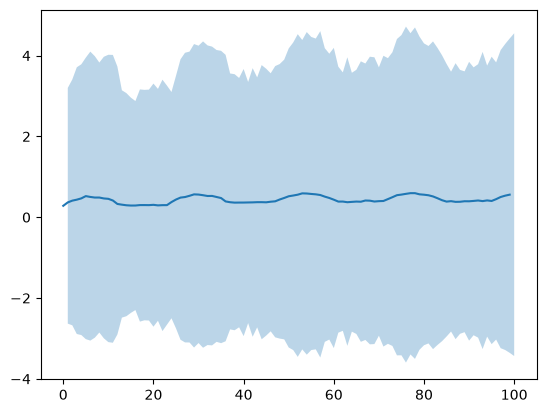

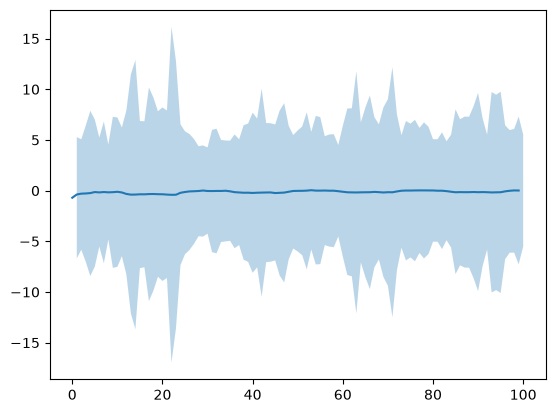

In [22]:


def get_horizon_error(errors):
    errors_array = np.stack(errors)
    print(errors_array.shape)
    mean = np.mean(errors_array, axis=0)
    std = np.std(errors_array, axis=0)
    max_val = np.max(errors_array, axis=0)
    lower = mean - 1.96 * std
    upper = mean + 1.96 * std
    x = np.arange(1, len(mean)+1)

    fig, ax = plt.subplots()

    ax.plot(mean)
    ax.fill_between(x,lower, upper, alpha=0.3, )
   

print("MSE ERRORS PER POSITION: ")
get_horizon_error(df["mse_losses_position"])
print("NLL ERRORS PER POSITION: ")
get_horizon_error(df["losses_position"])